Conectando a la NOAA para GeoColor (2024-10-15 16:00:00 UTC)...
Descargando archivo multibanda: OR_ABI-L2-MCMIPF-M4_G19_s20242891635204_e20242891640020_c20242891640091.nc...
Descarga completada.
Archivo multibanda cargado con éxito.
Procesando composición RGB para GeoColor...
Carimbo y logos adaptados correctamente para GeoColor.
¡Imagen GeoColor generada con éxito!: /Users/diegoperales/Meteorology/GOES/procesados/GOES19_GeoColor_SENAMHI_Bolivia_20241015_1637.png


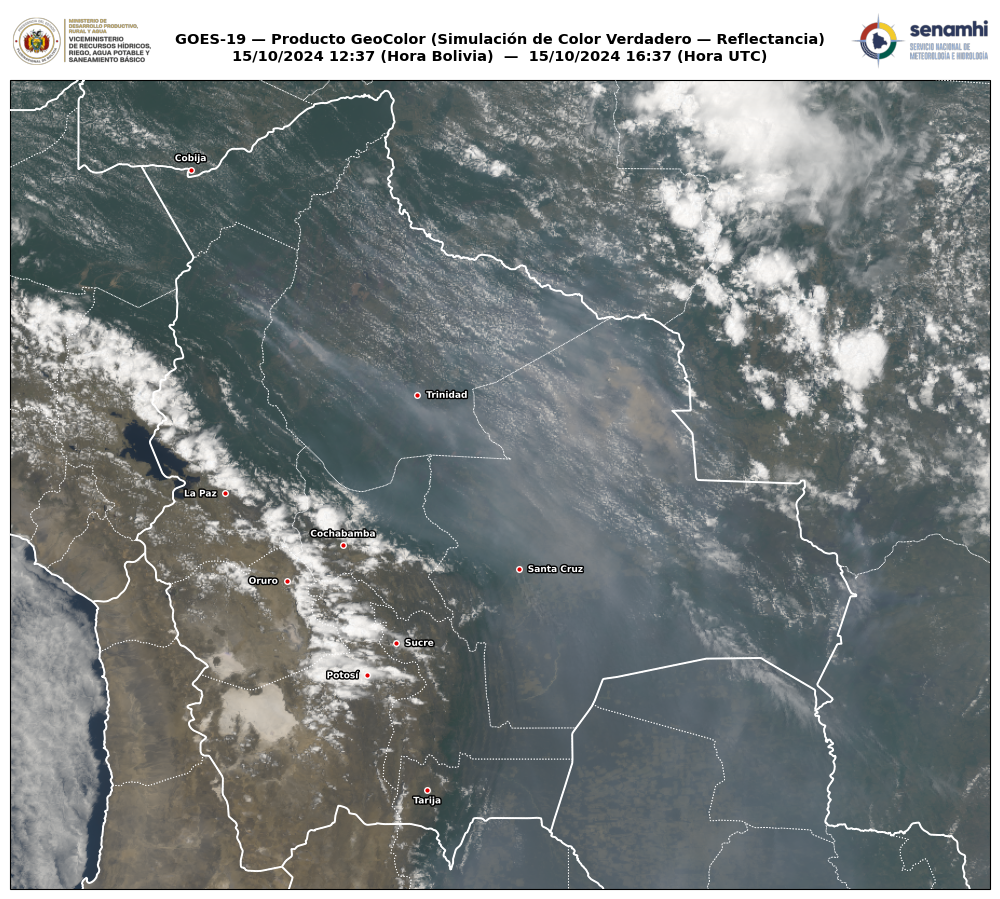

In [2]:
import os
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patheffects as patheffects
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import s3fs

# ==========================================
# 1. CONFIGURACIÓN DEL USUARIO
# ==========================================
FECHA_BUSCADA = datetime(2024, 10, 15, 16, 00) 

BASE_DIR = "/Users/diegoperales/Meteorology/GOES"
RAW_DATA = os.path.join(BASE_DIR, "raw_data")
OUTPUTS = os.path.join(BASE_DIR, "procesados")
os.makedirs(RAW_DATA, exist_ok=True)
os.makedirs(OUTPUTS, exist_ok=True)

# ==========================================
# 2. CONEXIÓN A AMAZON S3 (PRODUCTO MULTIBANDA MCMIPF)
# ==========================================
print(f"Conectando a la NOAA para GeoColor ({FECHA_BUSCADA} UTC)...")
fs = s3fs.S3FileSystem(anon=True)

doy = FECHA_BUSCADA.strftime('%j') 
anio = FECHA_BUSCADA.strftime('%Y')
hora = FECHA_BUSCADA.strftime('%H')

# Ruta para el GOES-19, Producto ABI Nivel 2 Multibanda Full Disk
s3_folder = f"noaa-goes19/ABI-L2-MCMIPF/{anio}/{doy}/{hora}/"

try:
    # Listar todos los archivos en esa carpeta horaria
    archivos = fs.ls(s3_folder)
    
    # CAMBIO COMPA: Filtramos de forma más abierta, solo que termine en .nc
    archivos_multi = [f for f in archivos if f.endswith('.nc')]
    
    if not archivos_multi:
        raise FileNotFoundError(f"No se encontró absolutamente ningún archivo NetCDF en la carpeta S3: {s3_folder}")
        
    # Seleccionamos el primer archivo disponible que liberó la NOAA para esa hora
    s3_path = archivos_multi[0]
    file_name = s3_path.split('/')[-1]
    local_path = os.path.join(RAW_DATA, file_name)
    
    if not os.path.exists(local_path):
        print(f"Descargando archivo multibanda: {file_name}...")
        fs.get(s3_path, local_path)
        print("Descarga completada.")
    else:
        print("El archivo ya existe en el almacenamiento local, cargando desde disco...")
        
    ds = xr.open_dataset(local_path)
    print("Archivo multibanda cargado con éxito.")

except Exception as e:
    print(f"Error crítico en la conexión/descarga: {e}")
    raise e

# ==========================================
# 3. EXTRACCIÓN DE PARÁMETROS Y PROYECCIÓN
# ==========================================
glob_attrs = ds.goes_imager_projection.attrs
height = glob_attrs['perspective_point_height']
lon_0 = glob_attrs['longitude_of_projection_origin']
sweep = glob_attrs['sweep_angle_axis']

dataprojenv = ccrs.Geostationary(central_longitude=lon_0, 
                                 satellite_height=height, 
                                 sweep_axis=sweep)

# ==========================================
# 4. RECETA MATEMÁTICA GEOCOLOR (TRUE COLOR SIMULADO)
# ==========================================
print("Procesando composición RGB para GeoColor...")
# El GOES no tiene banda verde pura de alta resolución, se simula combinando:
# R = Banda 2 (Visible Rojo)
# G = Pseudo-Verde (0.45 * Banda 2 + 0.1 * Banda 3 + 0.45 * Banda 1)
# B = Banda 1 (Visible Azul)

R = ds['CMI_C02'].data
B = ds['CMI_C01'].data
# El canal 3 es el infrarrojo cercano (vegetación) que ayuda a revivir el verde del bosque amazónico
G_pseudo = 0.45 * R + 0.1 * ds['CMI_C03'].data + 0.45 * B

# Normalizamos los reflectancias entre 0 y 1 para que la pantalla los lea bien
R = np.clip(R, 0, 1)
G = np.clip(G_pseudo, 0, 1)
B = np.clip(B, 0, 1)

# Aplicamos una corrección gamma (raiz cuadrada) para aclarar la atmósfera y resaltar los valles/llanos
gamma = 0.55
R = np.power(R, gamma)
G = np.power(G, gamma)
B = np.power(B, gamma)

# Apilamos los tres canales para crear la matriz de imagen RGB 3D
rgb_image = np.dstack((R, G, B))

# ==========================================
# 5. GENERACIÓN DEL PRODUCTO VISUAL
# ==========================================
fig, ax = plt.subplots(figsize=(10, 10), facecolor='white', 
                       subplot_kw={'projection': ccrs.PlateCarree()})

# Ajustamos márgenes (ganamos espacio abajo al no tener barra de colores)
fig.subplots_adjust(left=0.01, right=0.99, top=0.88, bottom=0.02)

ax.set_extent([-71.8, -55.2, -23.2, -9.5], crs=ccrs.PlateCarree())

# --- CAPA 1: IMAGEN RGB MEDIANTE IMSHOW (Nativo para color verdadero) ---
# Extraemos las coordenadas de los pixeles del satélite para proyectar correctamente
x = ds.x.data * height
y = ds.y.data * height

ax.imshow(rgb_image, origin='upper', transform=dataprojenv, 
          extent=[x.min(), x.max(), y.min(), y.max()], zorder=1)

# --- CAPA 2: LÍMITES GEOGRÁFICOS ---
COLOR_BLANCO = '#ffffff'
ax.add_feature(cfeature.COASTLINE, linestyle='-', edgecolor=COLOR_BLANCO, linewidth=1.4, zorder=3)
ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor=COLOR_BLANCO, linewidth=1.4, zorder=3)
ax.add_feature(cfeature.STATES, linestyle=(0, (1, 2)), edgecolor=COLOR_BLANCO, linewidth=0.7, zorder=4)

# --- CAPA 3: CAPITALES DE DEPARTAMENTO (TU COLO_MÁSTER CLONADO) ---
capitales = {
    "Cobija":        {"lat": -11.02, "lon": -68.74, "pos": "top"},
    "Trinidad":      {"lat": -14.83, "lon": -64.90, "pos": "right"},
    "La Paz":        {"lat": -16.50, "lon": -68.15, "pos": "left"},
    "Cochabamba":    {"lat": -17.38, "lon": -66.16, "pos": "top"},
    "Santa Cruz":    {"lat": -17.78, "lon": -63.18, "pos": "right"},
    "Oruro":         {"lat": -17.98, "lon": -67.11, "pos": "left"},
    "Sucre":         {"lat": -19.03, "lon": -65.26, "pos": "right"},
    "Potosí":        {"lat": -19.58, "lon": -65.75, "pos": "left"},
    "Tarija":        {"lat": -21.53, "lon": -64.73, "pos": "bottom"}
}

for ciudad, info in capitales.items():
    ax.plot(info["lon"], info["lat"], marker='o', color='#E50001', 
            markersize=4, markeredgecolor='white', markeredgewidth=1.0, 
            transform=ccrs.PlateCarree(), zorder=10)
    
    offset_lon = 0.15 if info["pos"] == "right" else (-0.15 if info["pos"] == "left" else 0)
    offset_lat = 0.15 if info["pos"] == "top" else (-0.22 if info["pos"] == "bottom" else -0.05)
    alignment_h = "left" if info["pos"] == "right" else ("right" if info["pos"] == "left" else "center")
    
    ax.text(info["lon"] + offset_lon, info["lat"] + offset_lat, ciudad,
            color='white', fontsize=6.5, fontweight='bold',
            horizontalalignment=alignment_h, transform=ccrs.PlateCarree(), zorder=11,
            path_effects=[patheffects.withStroke(linewidth=2, foreground='black')])

# --- CAPA 4: DOBLE HUSO HORARIO ---
fecha_utc = datetime.strptime(ds.t.dt.strftime('%Y-%m-%d %H:%M').item(), '%Y-%m-%d %H:%M')
fecha_bot = fecha_utc - timedelta(hours=4)

string_utc = fecha_utc.strftime('%d/%m/%Y %H:%M (Hora UTC)')
string_bot = fecha_bot.strftime('%d/%m/%Y %H:%M (Hora Bolivia)')

# --- CAPA 5: TÍTULO ADAPTADO ---
ax.set_title(f"GOES-19 — Producto GeoColor (Simulación de Color Verdadero — Reflectancia)\n{string_bot}  —  {string_utc}", 
             fontsize=10.5, fontweight='bold', pad=14, loc='center', linespacing=1.3)

# --- CAPA 7: POSICIONAMIENTO DINÁMICO DE LOGOS ---
PATH_LOGOS = os.path.join(BASE_DIR, "logos")
try:
    img_ministerio_path = os.path.join(PATH_LOGOS, "logo_ministerio.png")
    img_senamhi_path = os.path.join(PATH_LOGOS, "logo_senamhi.png")
    
    if os.path.exists(img_ministerio_path) and os.path.exists(img_senamhi_path):
        logo_ministerio = mpimg.imread(img_ministerio_path)
        logo_senamhi = mpimg.imread(img_senamhi_path)
        
        pos_mapa = ax.get_position()
        
        ax_logo_min = fig.add_axes([pos_mapa.x0, pos_mapa.y1 + 0.005, 0.14, 0.07]) 
        ax_logo_min.imshow(logo_ministerio)
        ax_logo_min.axis('off')
        
        ax_logo_sen = fig.add_axes([pos_mapa.x1 - 0.14, pos_mapa.y1 + 0.005, 0.14, 0.07]) 
        ax_logo_sen.imshow(logo_senamhi)
        ax_logo_sen.axis('off')
        print("Carimbo y logos adaptados correctamente para GeoColor.")
except Exception as e:
    print(f"Alerta con logos: {e}")

# Guardado
output_name = f"{OUTPUTS}/GOES19_GeoColor_SENAMHI_Bolivia_{fecha_utc.strftime('%Y%m%d_%H%M')}.png"
plt.savefig(output_name, dpi=200, bbox_inches='tight', pad_inches=0.03)
print(f"¡Imagen GeoColor generada con éxito!: {output_name}")

plt.show()